# ANN Lab 7

**Name:** Muhammad Taqui  
**Enrollment:** 01-136221-021  
**Date:** October 24, 2024

**Aim:** Apply stochastic gradient descent and the softmax activation function to design a neural network.

In [1]:
import numpy as np

np.random.seed(42)  # reproducibility

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(y_true, y_pred):
    num_samples = y_true.shape[0]
    log_likelihood = -np.log(y_pred[range(num_samples), y_true])
    loss = np.sum(log_likelihood) / num_samples
    return loss

def one_hot(y, num_classes):
    return np.eye(num_classes)[y]

def initialize_weights(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size) * 0.01
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.01
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2

def forward_pass(X, W1, b1, W2, b2):
    z1 = np.dot(X, W1) + b1
    a1 = np.maximum(0, z1)  # ReLU activation
    z2 = np.dot(a1, W2) + b2
    y_pred = softmax(z2)
    return y_pred, a1

def backward_pass(X, y, y_pred, a1, W1, b1, W2, b2, learning_rate):
    num_samples = X.shape[0]
    y_true = one_hot(y, y_pred.shape[1])

    dz2 = y_pred - y_true
    dW2 = np.dot(a1.T, dz2) / num_samples
    db2 = np.sum(dz2, axis=0, keepdims=True) / num_samples

    dz1 = np.dot(dz2, W2.T) * (a1 > 0)  # ReLU gradient
    dW1 = np.dot(X.T, dz1) / num_samples
    db1 = np.sum(dz1, axis=0, keepdims=True) / num_samples

    # Update weights with SGD
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    return W1, b1, W2, b2

def compute_accuracy(X, y, W1, b1, W2, b2):
    y_pred, _ = forward_pass(X, W1, b1, W2, b2)
    predictions = np.argmax(y_pred, axis=1)
    accuracy = np.mean(predictions == y)
    return accuracy


## Training loop

True stochastic gradient descent: one randomly drawn sample updates the weights per step, and per-epoch loss/accuracy are logged.

In [2]:
def train_neural_network(X, y, input_size, hidden_size, output_size, epochs, learning_rate, verbose=False):
    W1, b1, W2, b2 = initialize_weights(input_size, hidden_size, output_size)
    history = {"loss": [], "accuracy": []}

    for epoch in range(epochs):
        total_loss = 0
        # Shuffle each epoch so SGD sees samples in a different order
        indices = np.random.permutation(len(X))

        for i in indices:
            x_sample = X[i:i+1]
            y_sample = y[i:i+1]

            y_pred, hidden_layer = forward_pass(x_sample, W1, b1, W2, b2)
            loss = compute_loss(y_sample, y_pred)
            total_loss += loss

            W1, b1, W2, b2 = backward_pass(
                x_sample, y_sample, y_pred, hidden_layer, W1, b1, W2, b2, learning_rate
            )

            if verbose:
                print(f"Sample {i + 1}, Loss: {loss:.4f}")

        avg_loss = total_loss / len(X)
        accuracy = compute_accuracy(X, y, W1, b1, W2, b2)
        history["loss"].append(avg_loss)
        history["accuracy"].append(accuracy)

        print(f'Epoch {epoch + 1}/{epochs}, Avg Loss: {avg_loss:.4f}, Accuracy: {accuracy * 100:.2f}%')

    return W1, b1, W2, b2, history

X = np.array([[0.1, 0.5], [0.7, 0.2], [0.3, 0.8]])
y = np.array([0, 1, 0])

input_size = 2
hidden_size = 5
output_size = 2
epochs = 50
learning_rate = 0.2

trained_W1, trained_b1, trained_W2, trained_b2, history = train_neural_network(
    X, y, input_size, hidden_size, output_size, epochs, learning_rate
)


Epoch 1/50, Avg Loss: 0.7307, Accuracy: 66.67%
Epoch 2/50, Avg Loss: 0.7138, Accuracy: 66.67%
Epoch 3/50, Avg Loss: 0.7001, Accuracy: 66.67%
Epoch 4/50, Avg Loss: 0.6927, Accuracy: 66.67%
Epoch 5/50, Avg Loss: 0.6850, Accuracy: 66.67%
Epoch 6/50, Avg Loss: 0.6822, Accuracy: 66.67%
Epoch 7/50, Avg Loss: 0.6812, Accuracy: 66.67%
Epoch 8/50, Avg Loss: 0.6810, Accuracy: 66.67%
Epoch 9/50, Avg Loss: 0.6809, Accuracy: 66.67%
Epoch 10/50, Avg Loss: 0.6832, Accuracy: 66.67%
Epoch 11/50, Avg Loss: 0.6807, Accuracy: 66.67%
Epoch 12/50, Avg Loss: 0.6809, Accuracy: 66.67%
Epoch 13/50, Avg Loss: 0.6809, Accuracy: 66.67%
Epoch 14/50, Avg Loss: 0.6811, Accuracy: 66.67%
Epoch 15/50, Avg Loss: 0.6833, Accuracy: 66.67%
Epoch 16/50, Avg Loss: 0.6825, Accuracy: 66.67%
Epoch 17/50, Avg Loss: 0.6817, Accuracy: 66.67%
Epoch 18/50, Avg Loss: 0.6781, Accuracy: 66.67%
Epoch 19/50, Avg Loss: 0.6778, Accuracy: 66.67%
Epoch 20/50, Avg Loss: 0.6773, Accuracy: 66.67%
Epoch 21/50, Avg Loss: 0.6764, Accuracy: 66.67%
E

## Visualizing training progress

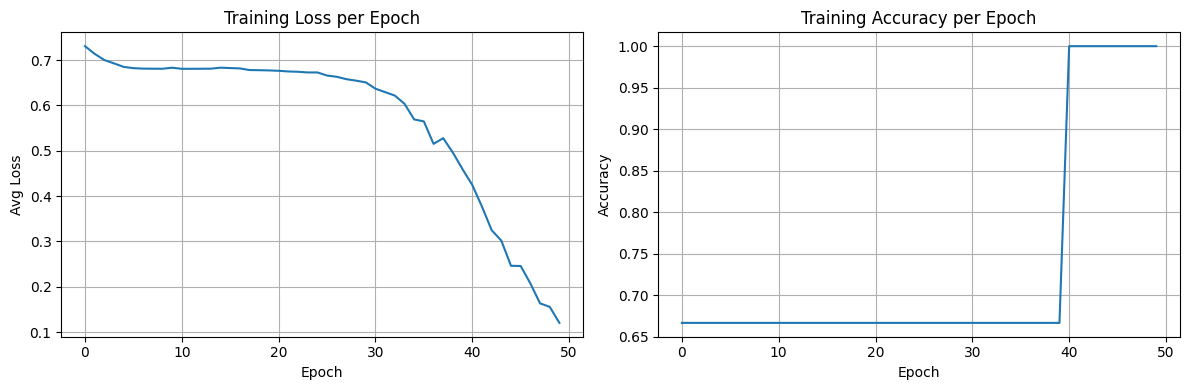

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["loss"])
axes[0].set_title("Training Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Avg Loss")
axes[0].grid(True)

axes[1].plot(history["accuracy"])
axes[1].set_title("Training Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 1. Stochastic Gradient Descent (SGD)

**Gradient Descent Overview:** Gradient descent is an optimization algorithm used to minimize the loss function (error) of a machine learning model. The core idea is to iteratively adjust the model's parameters (weights and biases) in the opposite direction of the gradient of the loss function with respect to those parameters. This helps find the point where the loss function is minimized.

- **Loss Function:** Measures how well the model is performing (e.g., cross-entropy for classification).
- **Gradients:** Indicate the direction and magnitude of the change needed to reduce the loss function.

### Variants of gradient descent

- **Batch Gradient Descent:** Updates the model weights after computing the gradients over the entire dataset. This can be slow for large datasets.
- **Stochastic Gradient Descent (SGD):** Updates the weights after computing the gradient for just one training example. This makes it faster but introduces noise in the updates.
- **Mini-batch Gradient Descent:** Combines aspects of both, updating the weights after computing the gradients for a small subset (batch) of the data.

### How SGD works

In Stochastic Gradient Descent, the model parameters are updated using a single, randomly selected training sample at a time:

1. **Randomly shuffle the dataset** before each epoch, to avoid cyclical patterns in the updates.
2. **Select one example at a time** from the dataset.
3. **Compute the gradient** of the loss function with respect to the model parameters for that sample.
4. **Update the weights** using: $\theta = \theta - \eta \nabla_\theta J(\theta)$, where $\theta$ represents the model parameters, $\eta$ is the learning rate, and $\nabla_\theta J(\theta)$ is the gradient of the loss $J(\theta)$.
5. **Repeat for each epoch** until the model converges.

**Advantages:** SGD is much faster than batch gradient descent for large datasets, and the frequent updates can help the model escape local minima.

**Challenges:** Updates are noisy, which can cause the loss to fluctuate (mitigated with momentum or learning rate schedules), and without proper tuning of the learning rate the model may fail to converge to the global minimum.

## 2. Softmax activation function

The softmax function is used in the output layer of a neural network for multi-class classification. It converts raw model outputs (logits) into a probability distribution over multiple classes, so the probabilities across all classes sum to 1.

For a given logit $z_i$ from class $i$: $\text{Softmax}(z_i) = \dfrac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}$

Softmax is well suited to multi-class classification because it constrains outputs to the range (0, 1) and lets the network's output be interpreted directly as class probabilities. For example, a softmax output of [0.2, 0.7, 0.1] implies a 20% probability of class 1, 70% of class 2, and 10% of class 3.

## 3. Neural network design using SGD and softmax

- **Input layer:** Takes in the input features.
- **Hidden layer(s):** Apply a non-linear activation (ReLU here); weights are updated via SGD.
- **Output layer:** Produces logits, which softmax converts into class probabilities.

During the forward pass, inputs flow through the hidden layer and softmax produces class probabilities at the output. During the backward pass, cross-entropy loss compares predicted probabilities to true labels, gradients are computed, and SGD updates the weights. This repeats across samples and epochs.

## 4. Mathematics involved

**Softmax:** $p_i = \dfrac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}$

**Cross-entropy loss:** $L = -\sum_{i=1}^{n} y_i \log(p_i)$

**SGD update rule:** $\theta = \theta - \eta \nabla_\theta L$

## Conclusion

Stochastic Gradient Descent provides an efficient way to optimize neural networks by updating parameters after each training example, leading to faster training compared to full-batch methods. Softmax, applied at the output layer, converts logits into a probability distribution suitable for multi-class classification. Together, these form the basis of many neural network classifiers, letting the network learn from data and adjust weights incrementally with each training sample.

// iTaqiZ - PK